# Customer Segmentation

### Questions that the clustering dataset should answer: 

- Who spends a lot?
- Who uses promotions?
- Who has families?
- Who is loyal?
- Who buys the most electronics?
- Who buys the most groceries?

This notebook aims to identify meaningful customer segments using K-Means clustering. The resulting segments will be analysed to understand customer behaviour and support the development of targeted marketing strategies.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:
customer_info = pd.read_csv("customer_info_clean.csv")

In [12]:
customer_info.shape

(33038, 26)

In [13]:
customer_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  float64
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   age                                      33038 non-null  float64
 4   kids_home                                33038 non-null  float64
 5   teens_home                               33038 non-null  float64
 6   number_complaints                        33038 non-null  float64
 7   distinct_stores_visited                  33038 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               33038 non-null  float64
 10  typical_hour                             33038

### Remove columns that should NOT be used for clustering

In [14]:
drop_cols = [
    'customer_id',      # identifier
    'customer_name',    # identifier
    'age_group'         # duplicate of age
]

customer_seg = customer_info.drop(columns=drop_cols)

## Encode Gender

In [ ]:
#  Since K-Means cannot process categorical text variables directly, the gender variable was encoded into numerical values.
customer_seg['customer_gender'].value_counts()

customer_gender
female    16577
male      16461
Name: count, dtype: int64

In [16]:
customer_seg['customer_gender'] = customer_seg['customer_gender'].map({
    'female': 0,
    'male': 1
})

In [17]:
customer_seg['customer_gender'].value_counts()

customer_gender
0    16577
1    16461
Name: count, dtype: int64

In [18]:
# Checking to make sure no all culumns are numeric.
customer_seg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_gender                          33038 non-null  int64  
 1   age                                      33038 non-null  float64
 2   kids_home                                33038 non-null  float64
 3   teens_home                               33038 non-null  float64
 4   number_complaints                        33038 non-null  float64
 5   distinct_stores_visited                  33038 non-null  float64
 6   lifetime_spend_groceries                 33038 non-null  float64
 7   lifetime_spend_electronics               33038 non-null  float64
 8   typical_hour                             33038 non-null  float64
 9   lifetime_spend_vegetables                33038 non-null  float64
 10  lifetime_spend_nonalcohol_drinks         33038

## Feature Selection

In [ ]:
# I decided to drop latitude and longitude because the goal of the
# clustering analysis is to identify customer purchasing behaviours
# rather than geographical patterns.

# I also removed has_loyalty_card from the clustering variables.
# Since one of the objectives is to identify loyal customers, including
# this variable could cause the clusters to be driven by existing loyalty
# card membership rather than underlying customer behaviour.

# The variable will be retained separately and used later for cluster
# profiling and interpretation.
customer_seg = customer_seg.drop(
    columns=[
        'latitude',
        'longitude',
        'has_loyalty_card'
    ]
)

In [20]:
customer_seg.shape

(33038, 20)

## Standardization

Since K-Means is distance-based, all variables were standardized to ensure that variables with larger magnitudes do not dominate the clustering process.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

customer_scaled = scaler.fit_transform(customer_seg)

customer_scaled = pd.DataFrame(
    customer_scaled,
    columns=customer_seg.columns
)

customer_scaled.head()

,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction
0,-0.996495,0.080407,0.016394,0.238641,0.146181,-0.096685,-0.393967,0.890367,-0.134436,-0.539432,-0.516478,-0.886736,-1.475436,-0.810334,-0.444257,-0.112396,0.319240,0.393485,1.125736,0.933618
1,-0.996495,-0.252436,0.016394,-1.127304,-1.175164,-0.704196,-0.196193,-0.609684,-0.134436,2.009069,0.258723,-1.053435,-1.443501,-1.221291,1.838389,0.253501,2.138811,-0.175329,-0.601680,-0.461969
2,1.003517,-0.030541,-1.271628,-1.127304,0.146181,-0.704196,-0.325860,-1.012066,-0.342479,-0.256438,-1.335976,-1.006678,1.158074,-0.685802,-0.521606,-0.848941,-0.729766,-0.647734,-0.891304,-2.056926
3,1.003517,-0.640753,-1.271628,-1.127304,1.467525,-1.311706,-0.820951,-0.550351,1.113819,-0.988802,1.085605,1.056741,0.534292,0.995384,-0.559421,2.168518,-0.975829,-0.541684,-0.229741,1.132987
4,1.003517,0.080407,-1.271628,-1.127304,2.128197,-1.311706,-0.650278,2.454767,0.905776,-0.528547,0.476518,0.213077,0.738671,0.854247,-0.882567,2.168518,0.688334,-1.370803,-0.470150,1.132987


## Elbow Method

### Determining the Optimal Number of Clusters

The Elbow Method was used to identify a suitable number of clusters by examining the reduction in within-cluster variation (inertia).

In [23]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(customer_scaled)

    inertia.append(kmeans.inertia_)

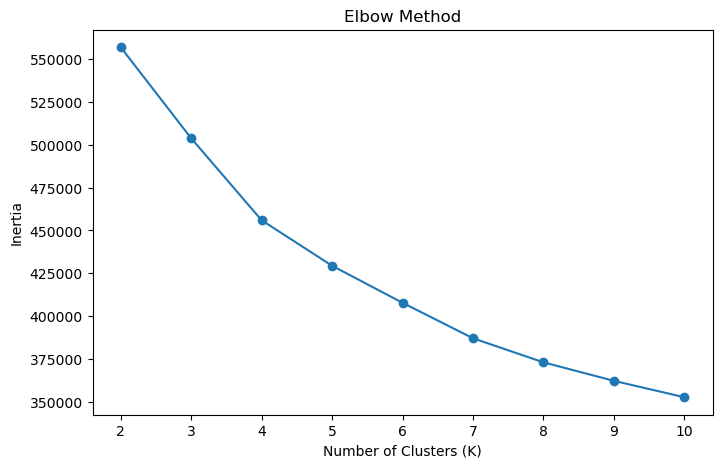

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Based on the elbow plot. It would seem that the optimal number of clusters lies around K = 4 because  the reduction in inertia begins to diminish beyond this point. But it alone can't be the deciding factor. 

## Silhouette Analysis

In [25]:
sil_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(customer_scaled)

    score = silhouette_score(
        customer_scaled,
        labels
    )

    sil_scores.append(score)

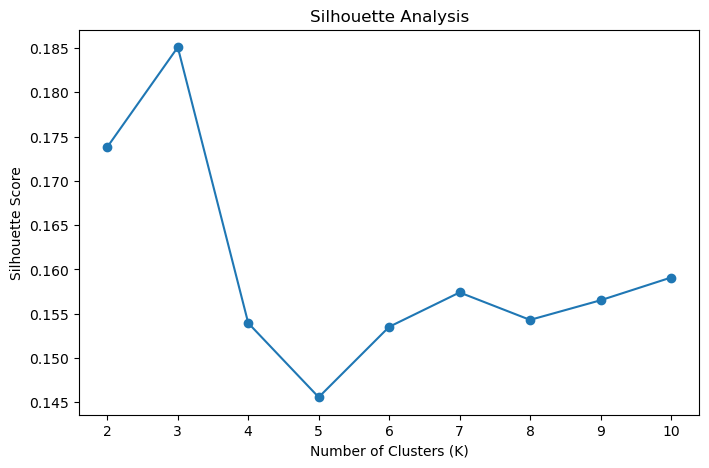

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    sil_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

The highest sihoutte score is K = 3

### Selecting the Number of Clusters

The Elbow Method suggested that a suitable number of clusters lies between 3 and 4. The Silhouette Score reached its maximum value at K=3, indicating better cluster separation.

Therefore, K = 3 was selected as the final number of clusters.

In [34]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(customer_scaled)
customer_seg['cluster'] = cluster_labels

In [35]:
cluster_profile = customer_seg.groupby('cluster').mean()

cluster_profile

,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction
cluster,,,,,,,,,,,,,,,,,,,,
0,0.498252,53.828688,0.943967,0.723306,0.845460,3.300293,12844.147595,1136.782718,11.909383,882.322185,350.658722,359.279859,516.874327,377.555962,824.051309,181.641501,333.063569,112.671572,0.325883,2015.679321
1,0.510309,57.890383,1.500384,1.383468,1.006019,3.595211,26478.150852,3960.675247,11.991548,555.132699,743.695928,1045.843066,1216.329748,1108.231976,1046.593290,349.913305,361.242541,269.209886,0.311993,2012.852798
2,0.475018,51.891952,0.226680,0.283780,0.893921,1.585774,9384.760276,6161.010829,17.742801,190.620262,508.033227,1104.347157,832.653458,809.820207,285.817130,655.199114,292.203913,100.590943,0.285835,2018.166872


In [36]:
pd.set_option('display.max_columns', None)

cluster_profile.round(2)

,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction
cluster,,,,,,,,,,,,,,,,,,,,
0,0.50,53.83,0.94,0.72,0.85,3.30,12844.15,1136.78,11.91,882.32,350.66,359.28,516.87,377.56,824.05,181.64,333.06,112.67,0.33,2015.68
1,0.51,57.89,1.50,1.38,1.01,3.60,26478.15,3960.68,11.99,555.13,743.70,1045.84,1216.33,1108.23,1046.59,349.91,361.24,269.21,0.31,2012.85
2,0.48,51.89,0.23,0.28,0.89,1.59,9384.76,6161.01,17.74,190.62,508.03,1104.35,832.65,809.82,285.82,655.20,292.20,100.59,0.29,2018.17


In [37]:
customer_seg['cluster'].value_counts()

cluster
0    21166
1     7809
2     4063
Name: count, dtype: int64

Cluster 0 is the largest segment, representing approximately 64% of customers. Cluster 1 accounts for around 24% of customers, while Cluster 2 is the smallest segment at approximately 12%.

The distribution suggests that the retailer's customer base is dominated by mainstream shoppers, while high-value and technology-oriented customers form smaller but strategically important segments.

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

customer_pca = pca.fit_transform(customer_scaled)

In [39]:
pca_df = pd.DataFrame(
    customer_pca,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = cluster_labels

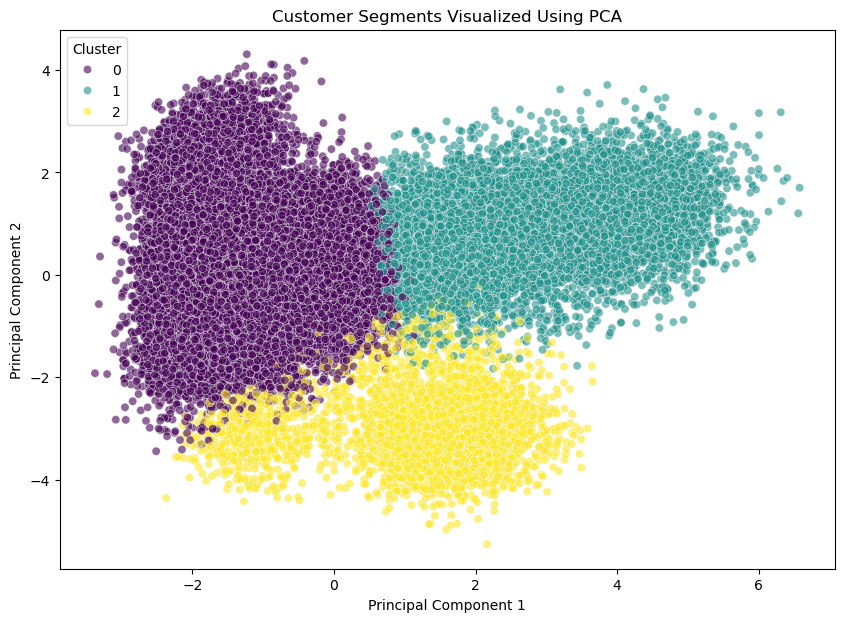

In [40]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    alpha=0.6
)

plt.title('Customer Segments Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.show()

In [41]:
pca.explained_variance_ratio_

array([0.19939755, 0.13136114])

In [42]:
print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

Total variance explained: 0.33075869060341223


Since the clustering model was trained using 20 standardized features, the clusters cannot be directly visualized in two dimensions. PCA was therefore used only for visualization purposes, reducing the scaled feature space into two principal components. The K-Means model itself was still fitted on the full scaled dataset.

The first two principal components explain approximately 33.1% of the variance in the dataset. Therefore, the PCA plot provides a simplified visualization of the cluster structure but does not capture all information used by the clustering model.

## Cluster interpretation 

In [43]:
cluster_percentages = (
    customer_seg['cluster'].value_counts(normalize=True).sort_index() * 100
).round(2)

cluster_percentages

cluster
0    64.07
1    23.64
2    12.30
Name: proportion, dtype: float64

In [44]:
cluster_profile = customer_seg.groupby('cluster').mean().round(2)
cluster_profile

,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction
cluster,,,,,,,,,,,,,,,,,,,,
0,0.50,53.83,0.94,0.72,0.85,3.30,12844.15,1136.78,11.91,882.32,350.66,359.28,516.87,377.56,824.05,181.64,333.06,112.67,0.33,2015.68
1,0.51,57.89,1.50,1.38,1.01,3.60,26478.15,3960.68,11.99,555.13,743.70,1045.84,1216.33,1108.23,1046.59,349.91,361.24,269.21,0.31,2012.85
2,0.48,51.89,0.23,0.28,0.89,1.59,9384.76,6161.01,17.74,190.62,508.03,1104.35,832.65,809.82,285.82,655.20,292.20,100.59,0.29,2018.17


In [45]:
overall_average = customer_seg.drop(columns='cluster').mean()

cluster_comparison = (
    customer_seg.groupby('cluster').mean() - overall_average
).round(2)

cluster_comparison

,customer_gender,age,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction
cluster,,,,,,,,,,,,,,,,,,,,
0,0.00,-0.72,-0.04,-0.10,-0.04,0.14,-2797.16,-1285.34,-0.74,162.40,-112.25,-253.91,-204.16,-225.87,13.59,-98.01,-1.64,-35.51,0.01,0.36
1,0.01,3.34,0.51,0.56,0.12,0.44,10836.85,1538.55,-0.65,-164.79,280.78,432.66,495.29,504.81,236.13,70.26,26.54,121.02,-0.01,-2.46
2,-0.02,-2.66,-0.76,-0.54,0.00,-1.57,-6256.54,3738.88,5.10,-529.30,45.12,491.16,111.62,206.40,-524.64,375.55,-42.50,-47.60,-0.03,2.85


In [46]:
for cluster in cluster_profile.index:
    print(f"\nCluster {cluster}")
    print(
        cluster_comparison.loc[cluster]
        .sort_values(ascending=False)
        .head(8)
    )


Cluster 0
lifetime_spend_vegetables                  162.40
lifetime_spend_hygiene                      13.59
year_first_transaction                       0.36
distinct_stores_visited                      0.14
percentage_of_products_bought_promotion      0.01
customer_gender                              0.00
number_complaints                           -0.04
kids_home                                   -0.04
Name: 0, dtype: float64

Cluster 1
lifetime_spend_groceries            10836.85
lifetime_spend_electronics           1538.55
lifetime_spend_fish                   504.81
lifetime_spend_meat                   495.29
lifetime_spend_alcohol_drinks         432.66
lifetime_spend_nonalcohol_drinks      280.78
lifetime_spend_hygiene                236.13
lifetime_total_distinct_products      121.02
Name: 1, dtype: float64

Cluster 2
lifetime_spend_electronics          3738.88
lifetime_spend_alcohol_drinks        491.16
lifetime_spend_videogames            375.55
lifetime_spend_fish        

In [47]:
for cluster in cluster_profile.index:
    print(f"\nCluster {cluster}")
    print(
        cluster_comparison.loc[cluster]
        .sort_values()
        .head(8)
    )


Cluster 0
lifetime_spend_groceries           -2797.16
lifetime_spend_electronics         -1285.34
lifetime_spend_alcohol_drinks       -253.91
lifetime_spend_fish                 -225.87
lifetime_spend_meat                 -204.16
lifetime_spend_nonalcohol_drinks    -112.25
lifetime_spend_videogames            -98.01
lifetime_total_distinct_products     -35.51
Name: 0, dtype: float64

Cluster 1
lifetime_spend_vegetables                 -164.79
year_first_transaction                      -2.46
typical_hour                                -0.65
percentage_of_products_bought_promotion     -0.01
customer_gender                              0.01
number_complaints                            0.12
distinct_stores_visited                      0.44
kids_home                                    0.51
Name: 1, dtype: float64

Cluster 2
lifetime_spend_groceries           -6256.54
lifetime_spend_vegetables           -529.30
lifetime_spend_hygiene              -524.64
lifetime_total_distinct_products   

In [48]:
customer_profile_full = customer_info.copy()
customer_profile_full['cluster'] = customer_seg['cluster']

customer_profile_full.groupby('cluster')['has_loyalty_card'].mean().round(2)

cluster
0    0.59
1    0.73
2    0.44
Name: has_loyalty_card, dtype: float64

In [49]:
cluster_profile.T

cluster,0,1,2
customer_gender,0.50,0.51,0.48
age,53.83,57.89,51.89
kids_home,0.94,1.50,0.23
teens_home,0.72,1.38,0.28
number_complaints,0.85,1.01,0.89
distinct_stores_visited,3.30,3.60,1.59
lifetime_spend_groceries,12844.15,26478.15,9384.76
lifetime_spend_electronics,1136.78,3960.68,6161.01
typical_hour,11.91,11.99,17.74
lifetime_spend_vegetables,882.32,555.13,190.62


## Time to answer the questions from the start of the notebook. 

- Who spends the most on shopping?
    - Cluster 1 appears to spend the most across all categories. 
- Who uses promotions the most?
    - Cluster 0 appears to have the highest percentage of products on promotion (33%) 
- Who has the highest number of families?
    - Cluster 1 appears to have the highest number of chilfren and teenagers at home. 
- Who is the most loyal?
    - Cluster 1 appears to have the most loyal segment of customers because it has:
        - the earliest first transaction year.
        - the highest product diversity.
        - the highest store visitation 
        - the highest number of customers who possess loyalty cards. 
        
        These indicators suggest a stronger and longer-lasting relationship with the retailer.
- Who buys the most electronics?
    - Cluster 2 appears to have the highest electronics and videogame spending. 
- Who buys the most groceries?
    - Cluster 1 appears to have the highest grocery expenditure. 

Based on the interpretations we can assign each cluster a name:
- Cluster 0 : Promotion-Oriented Mainstream Shoppers
- Cluster 1 : High-Value Family Customers
- Cluster 2 : Technology-Oriented Customers


| Cluster   | Size (%) | Suggested Name                         | Key Characteristics                                                                         |
| --------- | -------- | -------------------------------------- | ------------------------------------------------------------------------------------------- |
| Cluster 0 | 64.1%    | Promotion-Oriented Mainstream Shoppers | Moderate spending, highest promotion usage, medium household size                           |
| Cluster 1 | 23.6%    | High-Value Family Customers            | Highest grocery spending, largest households, most product variety, longest customer tenure |
| Cluster 2 | 12.3%    | Technology-Oriented Customers          | Highest electronics and videogame spending, smallest households, newest customers           |


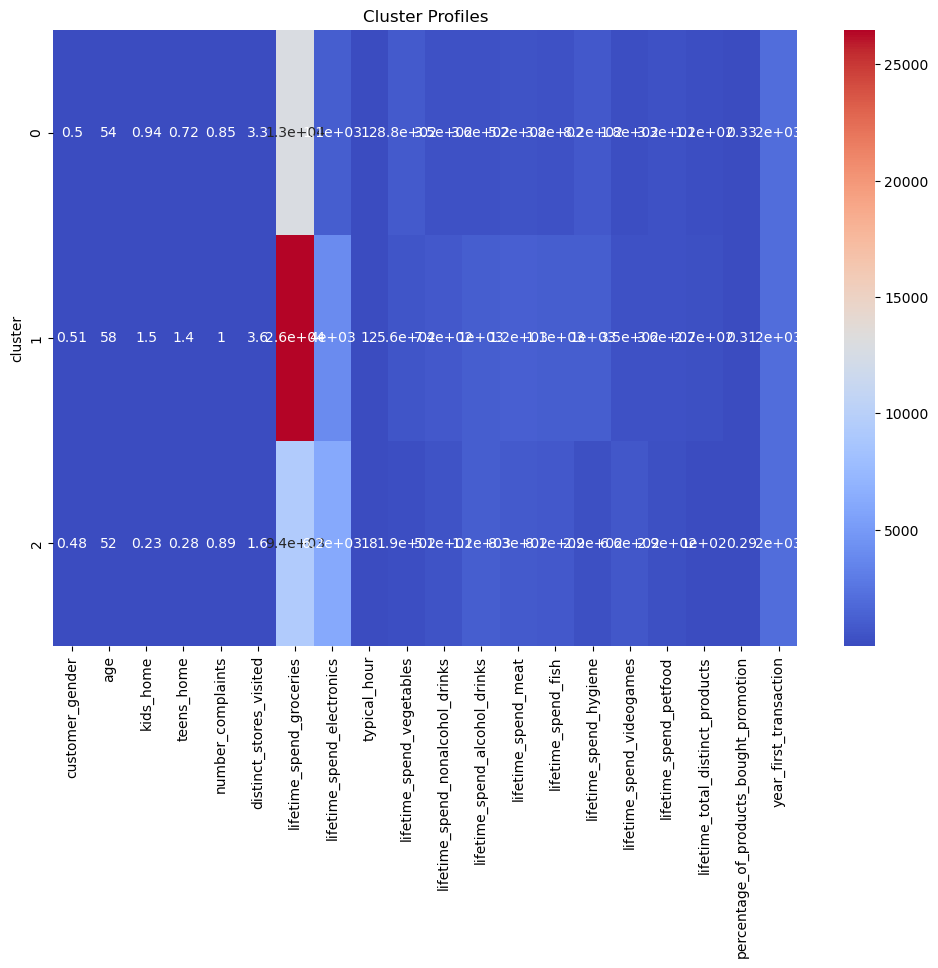

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm"
)
plt.title("Cluster Profiles")
plt.show()

## Conclusion

Three distinct customer segments were identified using K-Means clustering.

Cluster 0 represents promotion-oriented mainstream shoppers who demonstrate moderate spending behaviour and the highest use of promotional offers.

Cluster 1 represents high-value family customers characterised by the highest spending levels, largest households, greatest product variety and strongest loyalty indicators.

Cluster 2 represents technology-oriented customers who spend heavily on electronics and videogames while maintaining smaller household sizes.

These findings provide a foundation for developing targeted marketing strategies tailored to the needs and preferences of each customer segment.